# Multilayer CNN
## On MNIST dataset

In [76]:
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [77]:
# loading the data
mnist_bldr = tfds.builder('mnist')
mnist_bldr.download_and_prepare()
# shuffel false, beacuse we will split the training set into two parts: smaller training dataset and a validation dataset
# if shuffling was on, it would incur resuffling of the dataset each time we fetched a mini-batch of data
# can cause false performance estimation of the model
datasets = mnist_bldr.as_dataset(shuffle_files=False)
mnist_train_orig = datasets['train']
mnist_test_orig = datasets['test']

In [78]:
# preparing the dataset
BUFFER_SIZE = 10000
BATCH_SIZE = 64
NUM_EPOCHS = 20

mnist_train = mnist_train_orig.map(
    lambda item: (tf.cast(item['image'], tf.float32) / 255.0,
                  tf.cast(item['label'], tf.int32))
)

mnist_test = mnist_test_orig.map(
    lambda item: (tf.cast(item['image'], tf.float32) / 255.0,
                  tf.cast(item['label'], tf.int32))
)

tf.random.set_seed(1)

mnist_train = mnist_train.shuffle(buffer_size=BUFFER_SIZE,
                                  reshuffle_each_iteration = False)


mnist_valid = mnist_train.take(10000).batch(BATCH_SIZE)
mnist_train = mnist_train.skip(10000).batch(BATCH_SIZE)

In [79]:
# constructing the cnn
model = tf.keras.Sequential()
model.add(tf.keras.layers.Conv2D(
    filters=32, kernel_size=(5,5),
    strides=(1,1), padding='same',
    data_format='channels_last',
    name='conv_1', activation='relu')
)

model.add(tf.keras.layers.MaxPool2D(
    pool_size=(2,2), name='pool_1'
))

model.add(tf.keras.layers.Conv2D(
    filters=64, kernel_size=(5,5),
    strides=(1,1), padding='same',
    name='conv_2', activation='relu'
))

model.add(tf.keras.layers.MaxPool2D(
    pool_size=(2,2), name='pool_2'
))

In [80]:
# first dimension is batch dimension, used 16 for abitray,
# could have used none also
model.compute_output_shape(input_shape=(16,28,28,1))

(16, 7, 7, 64)

In [81]:
# next layer we want to add is dense (fully conected) 
# for implementing a classifier on top of conventionoal and pool layers
# input to this layer must have rank 2, that is the shape [batch_size x input_units]
# thus we need to flatten the output from previous layers to meet the requirments for the dense layer

model.add(tf.keras.layers.Flatten())
# verify that it has been faltened
model.compute_output_shape(input_shape=(16, 28, 28, 1))

(16, 3136)

In [82]:
# add two dense layers, with dropout in-between
model.add(tf.keras.layers.Dense(
    units=1024, name='fc1',
    activation='relu'
))

# half of the neurons are set to 0 (ps: only during training)
model.add(tf.keras.layers.Dropout(
    rate=0.5
))

model.add(tf.keras.layers.Dense(
    units=10, name='fc_2',
    activation='softmax'
))

In [83]:
# uses SpareseCategoricalCrossentopy because we have integer (sparse) labels instead of one-hot-encoded
tf.random.set_seed(1)
model.build(input_shape=(None, 28, 28, 1))

# adam optimizer, is a robust gradient-desect based optimization
# suited for nonconvex optimization and machine learning
# key advantage of adam is the choice of update step size derived from the running averrage of gradient movments
model.compile(
    optimizer = tf.keras.optimizers.Adam(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 1024)           │     3,212,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_2 (Dense)                    │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,274,634 (12.49 MB)

 Trainable params: 3,274,634 (12.49 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
# train the cnn model using the validation set for monitoring progress
history = model.fit(mnist_train, epochs=NUM_EPOCHS,
                    validation_data=mnist_valid,
                    shuffle=True)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9558 - loss: 0.1436 - val_accuracy: 0.9857 - val_loss: 0.0508
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.9861 - loss: 0.0444 - val_accuracy: 0.9823 - val_loss: 0.0599
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.9896 - loss: 0.0320 - val_accuracy: 0.9883 - val_loss: 0.0400
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - accuracy: 0.9926 - loss: 0.0224 - val_accuracy: 0.9896 - val_loss: 0.0386
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.9937 - loss: 0.0188 - val_accuracy: 0.9901 - val_loss: 0.0424
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.9947 - loss: 0.0161 - val_accuracy: 0.9897 - val_loss: 0.0414
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.9959 - loss: 0.0125 - val_accuracy: 0.9910 - val_loss: 0.0414
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.9962 - loss: 0.0114 - 

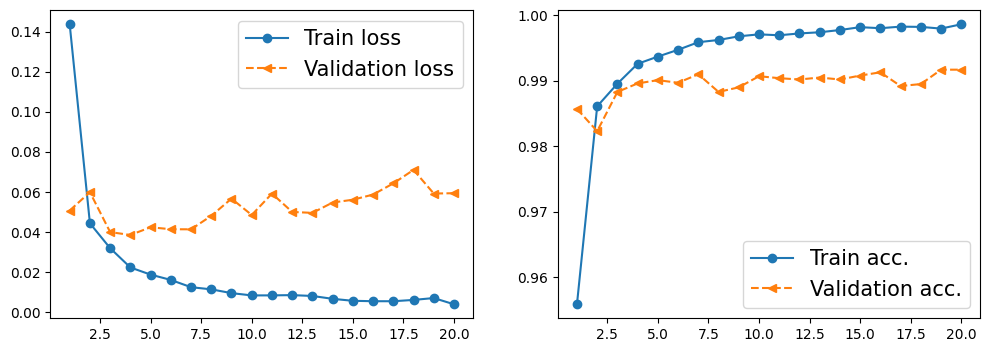

In [85]:
# visualize the training over the 20 epochs
hist = history.history
x_arr = np.arange(len(hist['loss'])) +1

fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(1,2,1)
ax.plot(x_arr, hist['loss'], '-o', label='Train loss')
ax.plot(x_arr, hist['val_loss'], '--<', label='Validation loss')
ax.legend(fontsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist['accuracy'], '-o', label='Train acc.')
ax.plot(x_arr, hist['val_accuracy'], '--<',
        label='Validation acc.')
ax.legend(fontsize=15)
plt.show()

TensorShape([12, 10])


W0000 00:00:1790943859.058021   25935 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


tf.Tensor([2 0 4 8 7 6 0 6 3 1 8 0], shape=(12,), dtype=int64)


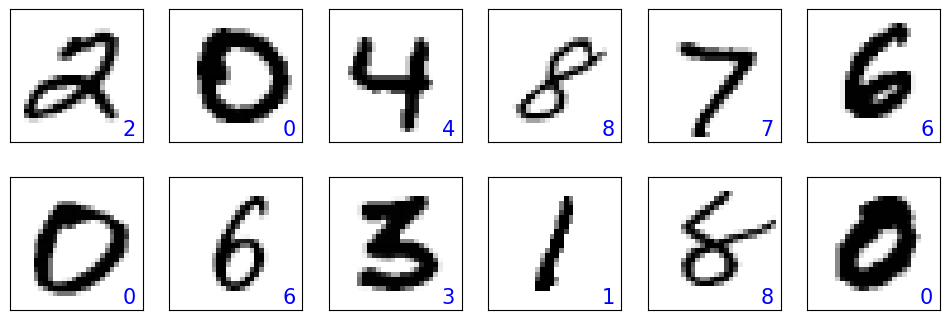

In [86]:
# can get the prediction in class-membership probabilities and convert them to predicited labels by using tf.argmax to find the element with maximium probability
# will do this for a batch of 12 examples and viszualize the input and predicted labels

batch_test = next(iter(mnist_test.batch(12)))

preds = model(batch_test[0])
tf.print(preds.shape)

preds = tf.argmax(preds, axis=1)
print(preds)


fig = plt.figure(figsize=(12,4))
for i in range(12):
    ax = fig.add_subplot(2,6, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    img = batch_test[0][i, :, :, 0]
    ax.imshow(img, cmap='gray_r')
    ax.text(0.9, 0.1,'{}'.format(preds[i]),
            size=15, color='blue',
            horizontalalignment='center',
            verticalalignment='center',
            transform=ax.transAxes)


plt.show()

In [87]:
# getting the missflassified 
mnist_test = mnist_test.batch(BATCH_SIZE)

evaluate_test = model.evaluate(mnist_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9925 - loss: 0.0391


Feilklassifiserte: 75 av 10000 testbilder
Andel feil: 0.75%


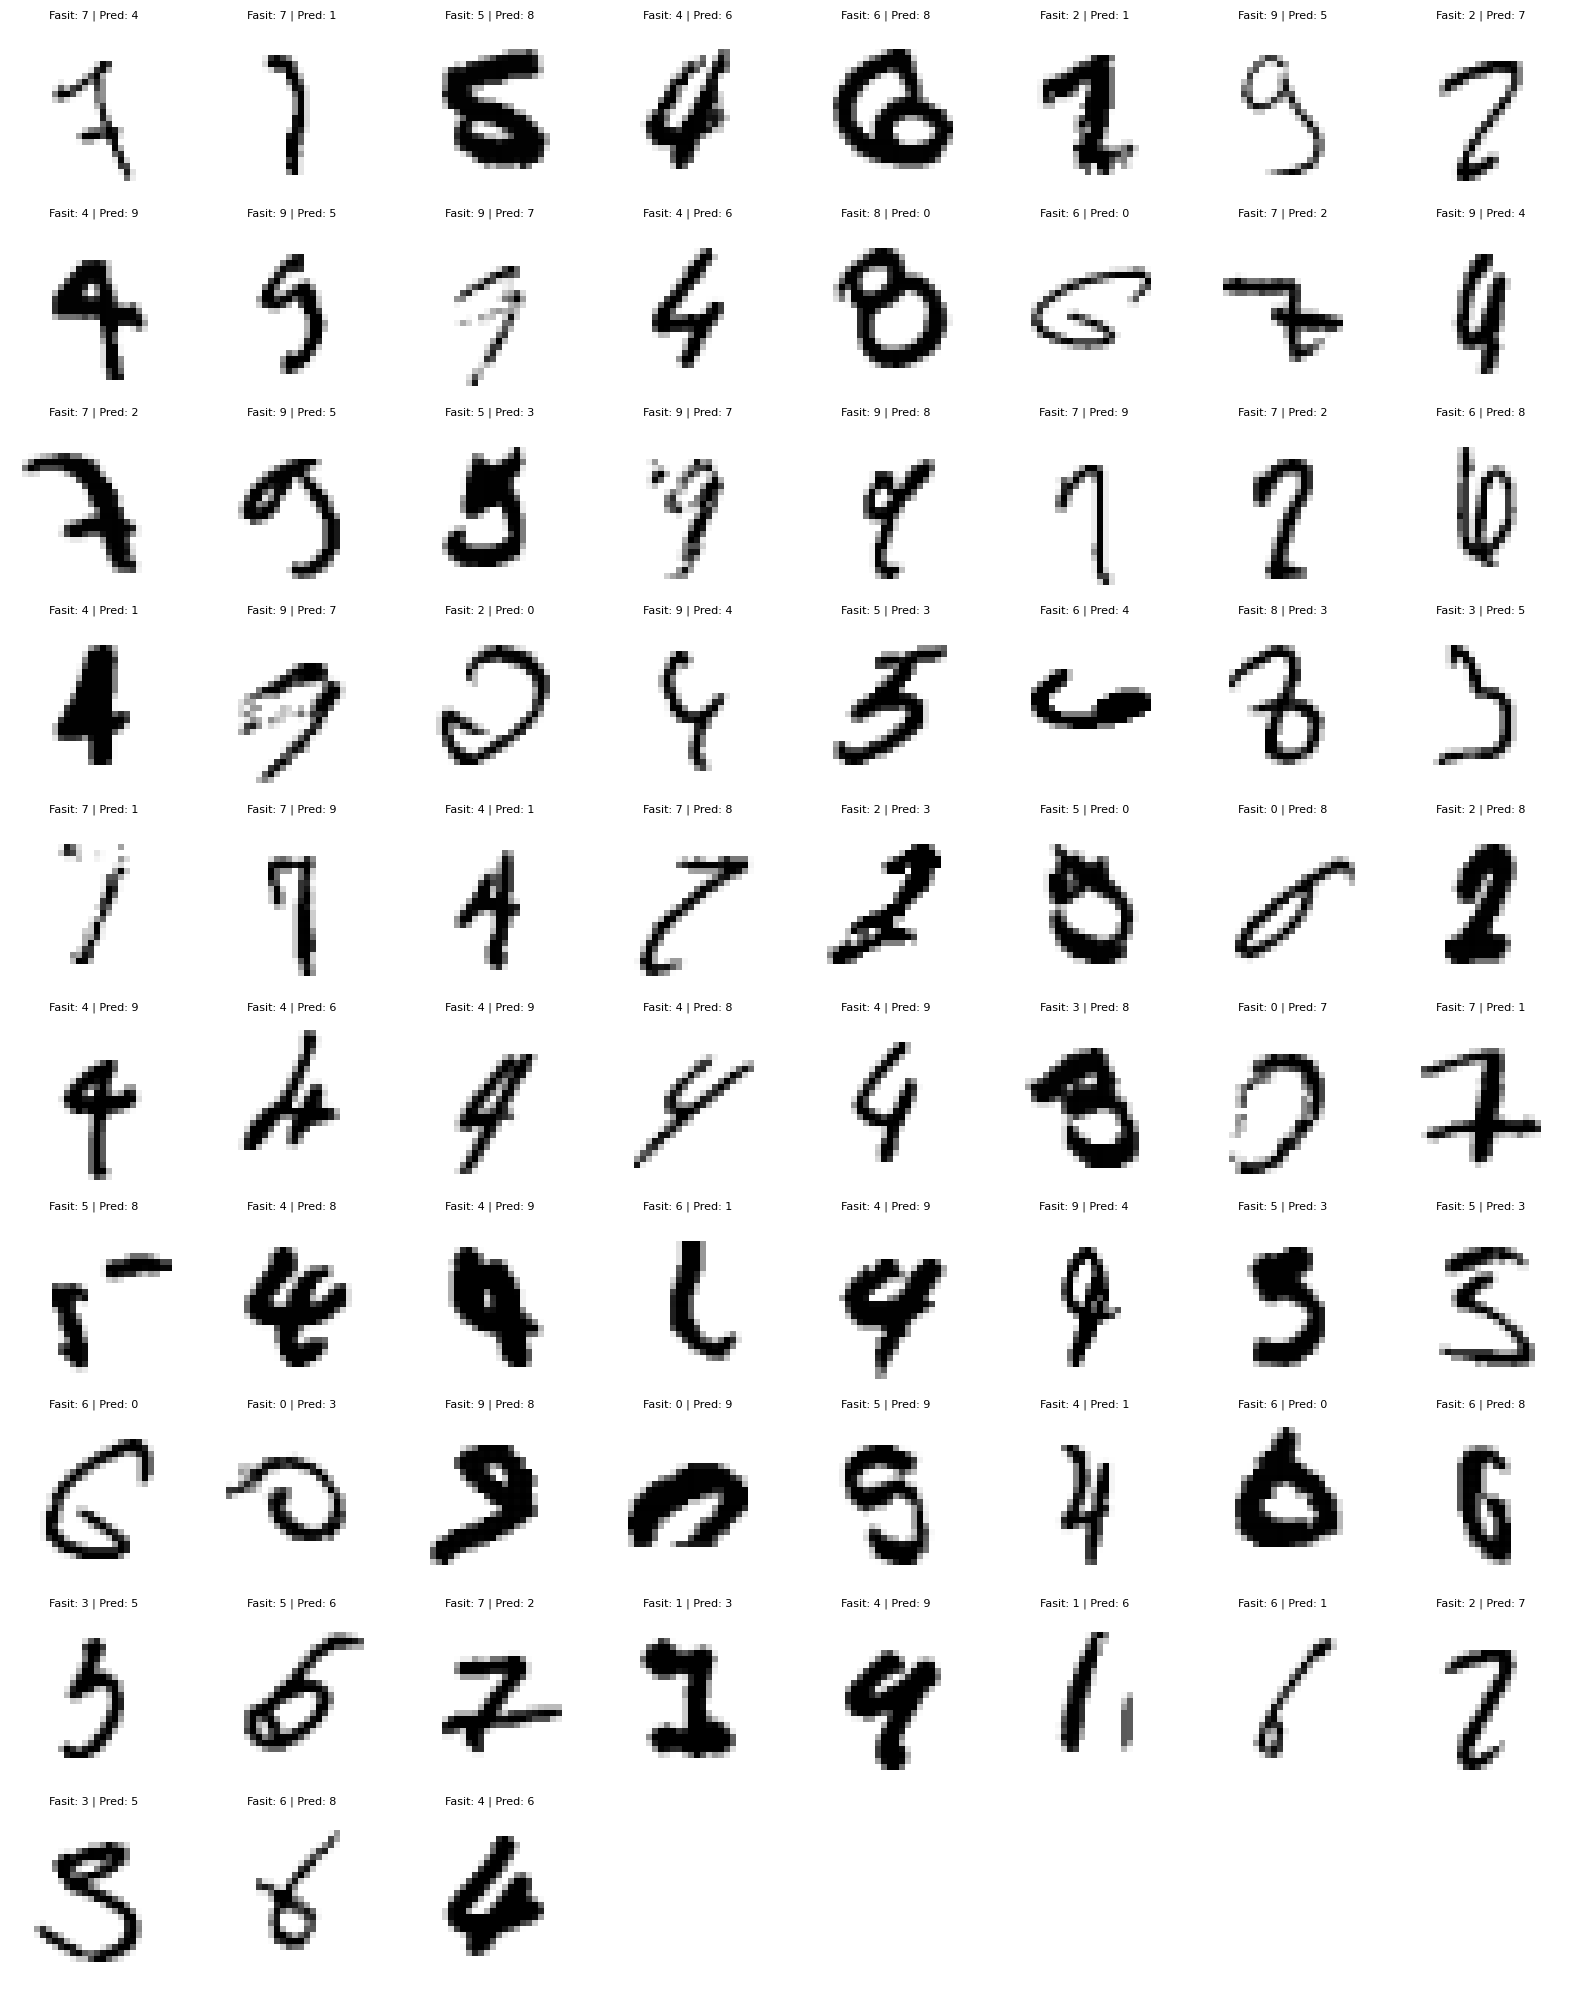

In [ ]:
# Finn alle feilklassifiserte eksempler i hele testsettet
all_test_images = []
all_test_labels = []
all_test_predictions = []

# gå gjennom testsettet
for images, labels in mnist_test:
    # Kaller modellen på bildene; resultatet er sannsynligheter for hver av de 10 klassene.
    # training=False gjør at dropout ikke slår av nevroner under evalueringen.
    probabilities = model(images, training=False)
    # Velger klassen med høyest sannsynlighet for hvert bilde i batchen.
    predictions = tf.argmax(probabilities, axis=1)
    # Lagrer bilder, etiketter og prediksjoner fra denne batchen.
    all_test_images.append(images.numpy())
    all_test_labels.append(labels.numpy())
    all_test_predictions.append(predictions.numpy())

# Slår sammen batchene til én array for hele testsettet.
all_test_images = np.concatenate(all_test_images)
all_test_labels = np.concatenate(all_test_labels)
all_test_predictions = np.concatenate(all_test_predictions)

# Sammenligningen lager True for feil og False for riktige prediksjoner.
# flatnonzero gir indeksene der sammenligningen er True.
misclassified_indices = np.flatnonzero(all_test_predictions != all_test_labels)
# Teller hvor mange eksempler som ble behandlet totalt.
num_test_examples = len(all_test_labels)
# Teller antall feil ved å telle indeksene som ble funnet over.
num_misclassified = len(misclassified_indices)

# Skriver ut antall feil og totalt antall testbilder.
print(f'Feilklassifiserte: {num_misclassified} av {num_test_examples} testbilder')
# Skriver ut hvor stor prosentandel av testbildene som ble feilklassifisert.
print(f'Andel feil: {100 * num_misclassified / num_test_examples:.2f}%')

if num_misclassified:

    columns = 8
    rows = int(np.ceil(num_misclassified / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(16, 2 * rows), squeeze=False)

    for axis in axes.flat:
        axis.axis('off')

    for axis, index in zip(axes.flat, misclassified_indices):
        axis.imshow(all_test_images[index, :, :, 0], cmap='gray_r')
        axis.set_title(
            f"Fasit: {all_test_labels[index]} | Pred: {all_test_predictions[index]}",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()
else:
    print('Ingen feilklassifiserte testbilder.')